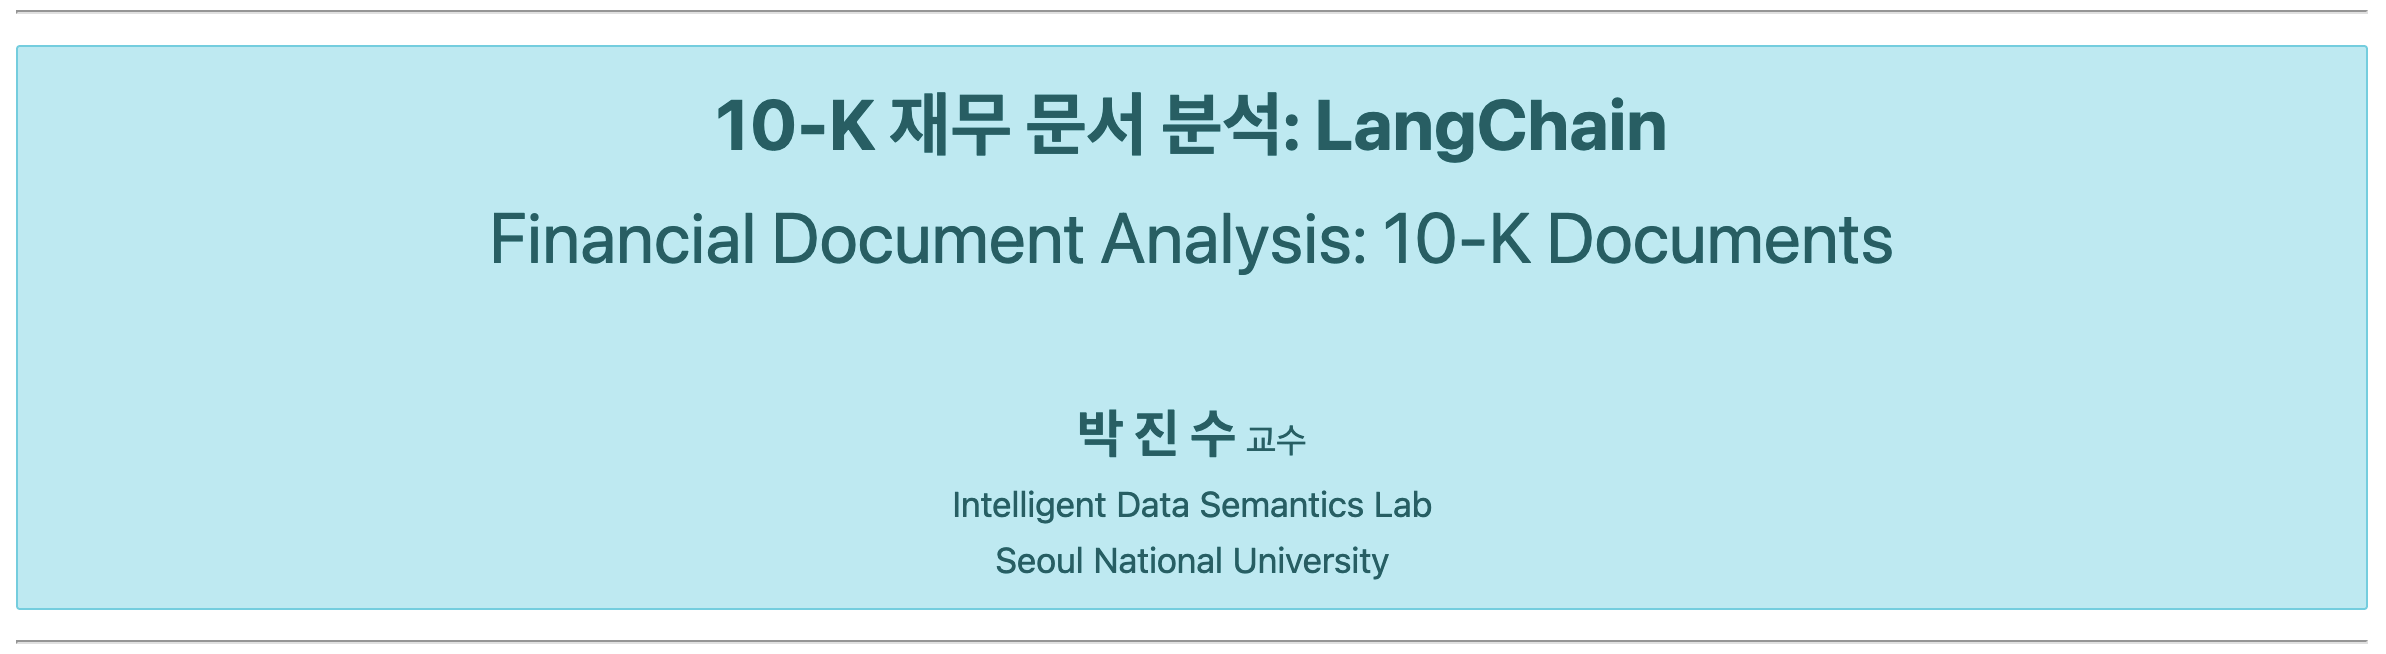

- - -    

- 본 자료는 강의를 위한 목적으로 LangChain이 제공하는 자료에 기반하여 제작했습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

> 파이썬 입문자라면, <http://youtube.com/@myontology>의 **[[학습 프로그램]](https://www.youtube.com/@myontology/courses)** 탭을 활용해 보세요. 기초부터 차근차근 배울 수 있는 파이썬 강의 영상이 준비되어 있어 필요한 내용을 쉽고 빠르게 학습할 수 있습니다.

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span></li><li><span><a href="#벡터-저장소에서-데이터-불러오기" data-toc-modified-id="벡터-저장소에서-데이터-불러오기-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>벡터 저장소에서 데이터 불러오기</a></span></li><li><span><a href="#도우미-함수-가져오기" data-toc-modified-id="도우미-함수-가져오기-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>도우미 함수 가져오기</a></span></li><li><span><a href="#생성(generation)" data-toc-modified-id="생성(generation)-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>생성(generation)</a></span><ul class="toc-item"><li><span><a href="#검색추출기-구성" data-toc-modified-id="검색추출기-구성-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>검색추출기 구성</a></span></li><li><span><a href="#시스템-프롬프트" data-toc-modified-id="시스템-프롬프트-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>시스템 프롬프트</a></span></li><li><span><a href="#모델-초기화" data-toc-modified-id="모델-초기화-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>모델 초기화</a></span></li><li><span><a href="#답변-생성" data-toc-modified-id="답변-생성-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>답변 생성</a></span></li></ul></li><li><span><a href="#에이전트-기반-RAG-구성" data-toc-modified-id="에이전트-기반-RAG-구성-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>에이전트 기반 RAG 구성</a></span></li><li><span><a href="#단일-문서-질의" data-toc-modified-id="단일-문서-질의-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>단일 문서 질의</a></span></li><li><span><a href="#여러-문서-비교-및-대조" data-toc-modified-id="여러-문서-비교-및-대조-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>여러 문서 비교 및 대조</a></span></li><li><span><a href="#문서와-관련-없는-질문" data-toc-modified-id="문서와-관련-없는-질문-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>문서와 관련 없는 질문</a></span></li></ul></div>

# 패키지 설치 및 API 설정

In [ ]:
!python -m pip install -qU python-dotenv langchain langchain-chroma # YOUR LLM package HERE(e.g., openai anthropic google-genai groq mistralai ollama)
print('--- Installation Completed', '-' * 55, '\n')

In [1]:
# 방법 1 - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

True

In [ ]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

- - -
**RAG**(Retrieval-Augmented Generation)는 주로 두 개의 구성 요소로 구분할 수 있다.
1. **인덱싱(indexing)**: 데이터 소스에서 데이터를 취득하고 색인화하는 과정
    + 일반적으로 이 과정은 오프라인에서 이루어진다.
2. **검색 추출(retrieval) 및 생성(generation)**: 사용자의 질의에 따라 적절한 데이터를 검색하고 모델(LLM)에 전달하여 답변을 생성하는 과정

이전 실습에서 RAG의 첫 번째 단계인 **인덱싱** 과정을 학습하였다.  
1. **데이터 로드(적재)**(document loading): 데이터를 로드(적재)
2. **데이터 분할**(document chunking): 큰 문서를 작은 청크(chunk)로 분할
	+ 이는 데이터 인덱싱 뿐만 아니라 언어모델로 입력할 때 유용하다.
	+  큰 청크는 검색하기 어렵고 모델의 제한적인 컨텍스트 윈도우에 맞지 않을 수 있다.
3. **데이터 저장**(vectorstore): 분할한 데이터를 저장하고 색인화할 수 있는 공간인 **벡터 저장소**와 **임베딩 모델**을 사용하여 수행
4. 벡터 저장소에서 직접 검색 추출 과정을 수행

이번 실습에서는 RAG의 두 번째 단계인 **검색 추출 및 생성** 과정을 학습한다.  

1. **검색 추출**(retrieval): 사용자의 질의에 따라 저장한 데이터에서 관련 청크를 검색한다.
2. **생성**(generation): 검색한 청크와 질문을 포함하고 있는 프롬프트를 사용하여 LLM(large language model, 대규모 언어 모델)이 답변을 생성한다.

- - -

# 벡터 저장소에서 데이터 불러오기

In [2]:
# --- load from disk
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_openai import OpenAIEmbeddings


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 임베딩 모델 둘 중 하나를 선택한다. ('text-embedding-3-large'을 추천)
embeddings  = 
path        = 
vectorstore = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

print(vectorstore._collection.count())

1854


# 도우미 함수 가져오기

In [ ]:
# --- utils.py 다운로드
!gdown 1UHksqU7wivF2308wDwEfz8Jf9-qsWyWi -O utils.py

# 생성(generation)

## 검색추출기 구성 

In [ ]:
# --- 검색추출기(retriever) 구성

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

retriever = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

## 시스템 프롬프트

In [ ]:
INSTRUCTION = '''제공 받은 
문서만을 참고하여 질문에 답하세요. 
자신의 내부 지식으로 답하지 마세요.
답을 모르면, 그냥 모른다고 말하세요. 

사용자의 질문과 동일한 언어로 응답하세요.
예를 들어, 사용자가 영어로 질문하면 영어로, 
한국어로 질문하면 한국어로 답변하세요.

일반 텍스트로만 응답해 주세요. 
마크다운 문법은 사용하지 말아 주세요.
'''

## 모델 초기화

In [ ]:
# --- 모델 초기화
from langchain.chat_models import init_chat_model

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

model = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

## 답변 생성

In [8]:
from langchain.messages import SystemMessage, HumanMessage
from utils import extract_text

question = '''2025년 Google의 순이익은 얼마입니까? 억 달러 단위로 반올림해서 답변하세요. 
그리고 참고한 페이지 번호도 알려주세요.
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

messages = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

result = model.invoke(messages)
print(extract_text(result))

2025년 순이익은 약 1,322억 달러로 반올림했습니다. (참고: Consolidated Statements of Income, 페이지 49)


# 에이전트 기반 RAG 구성

In [ ]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_core.documents import Document  
from langchain.chat_models import init_chat_model

# --- 검색추출기(retriever) 도구 정의
@tool(response_format='content_and_artifact')
def retriever_tool(query: str) -> tuple[str, list[Document]]:
    """Retrieve information to help answer a query."""
    
    # %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
    
    retrieved_docs = 
    context = 
    return context, retrieved_docs

    # %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


# --- 시스템 프롬프트
INSTRUCTION = '''반드시 최종 답변을 생성하기 전에 
검색추출 도구를 최소 한 번 이상 호출해야 합니다.
자신의 내부 지식으로 답하지 마세요.

검색추출 결과를 바탕으로 질문에 정확히 답변하세요. 
답변할 때 참고한 페이지 번호도 반드시 알려 주세요.
답을 모르면, 그냥 모른다고 말하세요. 

사용자의 질문과 동일한 언어로 응답하세요.
예를 들어, 사용자가 영어로 질문하면 영어로, 
한국어로 질문하면 한국어로 답변하세요.

일반 텍스트로만 응답해 주세요. 
마크다운 문법은 사용하지 말아 주세요.
'''



# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# --- 모델 초기화
# 모델을 바꿔 테스트하려면 init_chat_model을 사용한다.
model = 

# --- 에이전트 구성
agent = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [11]:
retriever_tool

StructuredTool(name='retriever_tool', description='Retrieve information to help answer a query.', args_schema=<class 'langchain_core.utils.pydantic.retriever_tool'>, response_format='content_and_artifact', func=<function retriever_tool at 0x10fa4d940>)

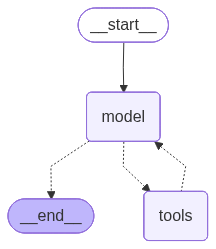

In [12]:
agent

# 단일 문서 질의

In [15]:
from langchain.messages import HumanMessage

question = '2025년 Google의 순이익은 얼마입니까? 억 달러 단위로 반올림해서 답변하세요.'
result   = agent.invoke({'messages': [HumanMessage(question)]})
print(extract_text(result))

2025년 Google(Alphabet)의 순이익은 1,321.7억 달러입니다(= 132,170 million 달러). 억 달러 단위로 반올림하면 1,322억 달러입니다.

출처: Alphabet Inc. 2025 Form 10-K(재무제표) 연결손익계산서(Consolidated Statements of Income) 50쪽(문서 페이지 49, “Net income $ 132,170” (in millions)).


In [16]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

2025년 Google의 순이익은 얼마입니까? 억 달러 단위로 반올림해서 답변하세요.
================================== Ai Message ==================================
Tool Calls:
  retriever_tool (call_OSM302onqxlYuKSqVXzGAgXe)
 Call ID: call_OSM302onqxlYuKSqVXzGAgXe
  Args:
    query: 2025 Google net income amount 2025 Alphabet net income 2025 annual report
================================= Tool Message =================================
Name: retriever_tool

Source: {'creator': 'Workiva', 'source': '/Users/jinsoopark/Dropbox/_data/projects/python/datasets/texts/10k/google-10k-2025.pdf', 'creationdate': '2026-02-05T11:03:36+00:00', 'author': 'anonymous', 'total_pages': 99, 'page': 49, 'producer': 'Wdesk Fidelity Content Translations Version 014.009.031', 'moddate': '2026-02-05T11:03:36+00:00', 'page_label': '50', 'title': 'GOOG 10-K 2025'}
Content: Alphabet Inc.
CONSOLIDATED STATEMENTS OF INCOME
(in millions, except per share amounts)
 Year E

In [ ]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# > Apple의 순이익


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [ ]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# > Uber의 순이익


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [ ]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# > Lyft의 순이익


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [ ]:
question = '2024년부터 2025년까지 Uber의 가장 빠르게 성장한 고객 세그먼트를 알려주세요.'
result   = agent.invoke({'messages': [HumanMessage(question)]})
print(extract_text(result))

In [ ]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# > Apple의 가장 빠르게 성장한 고객 세그먼트


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [ ]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# > Google의 가장 빠르게 성장한 고객 세그먼트


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [ ]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# > Lyft의 가장 빠르게 성장한 고객 세그먼트


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [ ]:
question = '2024년부터 2025년까지 Apple의 가장 빠르게 성장한 지역을 알려주세요.'
result   = agent.invoke({'messages': [HumanMessage(question)]})
print(extract_text(result))

In [ ]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# > Google의 가장 빠르게 성장한 지역


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [ ]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# > Uber의 가장 빠르게 성장한 지역


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [ ]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# > Lyft의 가장 빠르게 성장한 지역


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 여러 문서 비교 및 대조

In [ ]:
question = '2024년부터 2025년까지 Apple과 Google의 매출 성장을 비교하세요.'
result   = agent.invoke({'messages': [HumanMessage(question)]})
print(extract_text(result))

In [ ]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# > Uber와 Lyft의 매출 성장 비교


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [ ]:
question = 'Apple과 Google의 고객 세그먼트를 비교하고 대조 분석하세요.'
result   = agent.invoke({'messages': [HumanMessage(question)]})
print(extract_text(result))

In [ ]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# > Uber와 Lyft의 고객 세그먼트 비교


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [ ]:
question = '2024년부터 2025년까지 Apple과 Google의 가장 빠르게 성장한 지역을 비교하고 대조 분석하세요.'
result   = agent.invoke({'messages': [HumanMessage(question)]})
print(extract_text(result))

In [ ]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# > Uber와 Lyft의 가장 빠르게 성장한 지역 비교


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 문서와 관련 없는 질문

In [7]:
question = '2026년 가장 핫한 뉴스가 뭔가요?'
result   = agent.invoke({'messages': [HumanMessage(question)]})
print(extract_text(result))

검색 결과만으로는 “2026년 가장 핫한 뉴스”가 무엇인지 단정할 수 없습니다. 검색된 자료가 일반 뉴스 종합이 아니라 주로 기업 10-K 문서라서, 전 세계적으로 가장 화제가 된 뉴스 순위를 판단할 근거가 부족합니다.

다만 검색 결과에서 확인되는 2026년 관련 주요 이슈는 다음입니다.

1. Alphabet/Google이 2025년에 Wiz를 320억 달러, Intersect를 48억 달러에 인수하기로 했고, 두 거래 모두 2026년에 마무리될 것으로 예상된다고 공시했습니다. 참고: Google 2025 Form 10-K, 페이지 34

2. Waymo가 2026년 2월 160억 달러 규모의 투자 라운드를 발표했으며, 대부분은 Alphabet이 자금을 댔다고 공시했습니다. 참고: Google 2025 Form 10-K, 페이지 34

3. Apple은 2025년에 iOS 26, macOS Tahoe 26, iPadOS 26, watchOS 26, visionOS 26, tvOS 26 등을 발표했다고 공시했습니다. 이는 “26” 버전 관련 기술 뉴스로는 참고할 수 있지만, 2026년의 일반 뉴스라고 보기는 어렵습니다. 참고: Apple 2025 Form 10-K, 페이지 24

따라서 검색된 자료 기준으로는 “2026년 가장 핫한 뉴스”를 하나로 꼽기는 어렵고, 확인 가능한 2026년 관련 큰 이슈는 Google의 Wiz/Intersect 인수 마무리 예상과 Waymo의 160억 달러 투자 발표입니다.


In [8]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

2026년 가장 핫한 뉴스가 뭔가요?
================================== Ai Message ==================================
Tool Calls:
  retriever_tool (call_3Kiux9vgLdnjYqQbL3xkynAE)
 Call ID: call_3Kiux9vgLdnjYqQbL3xkynAE
  Args:
    query: 2026년 주요 뉴스 2026 top news May 2026
================================= Tool Message =================================
Name: retriever_tool

Source: {'page_label': '24', 'page': 23, 'producer': 'Wdesk Fidelity Content Translations Version 014.006.087', 'subject': '10-K 2025, 09.27.2025', 'moddate': '2025-10-30T08:52:59-07:00', 'source': '/Users/jinsoopark/Dropbox/_data/projects/python/datasets/texts/10k/apple-10k-2025.pdf', 'title': '_10-K 2025 (As-Filed)', 'creator': 'Workiva', 'author': 'anonymous', 'creationdate': '2025-10-30T14:45:03+00:00', 'total_pages': 80}
Content: • iMac
• iPad mini
Second Quarter 2025:
• iPhone 16e
• iPad Air
• iPad
• MacBook Air
• Mac Studio
Third Quarter 2025:
•

In [42]:
question = '세종대왕에 대한 설명을 해주세요.'
result   = agent.invoke({'messages': [HumanMessage(question)]})
print(extract_text(result))

죄송하지만, 제공된 검색 결과에서는 “세종대왕”에 대한 자료를 찾을 수 없었습니다. (검색으로 확인한 문서는 “GOOG 10-K 2025”이며 세종대왕 관련 내용이 없습니다: 3~6페이지)

따라서 검색 결과를 바탕으로 세종대왕을 정확히 설명해 드릴 수 없습니다.


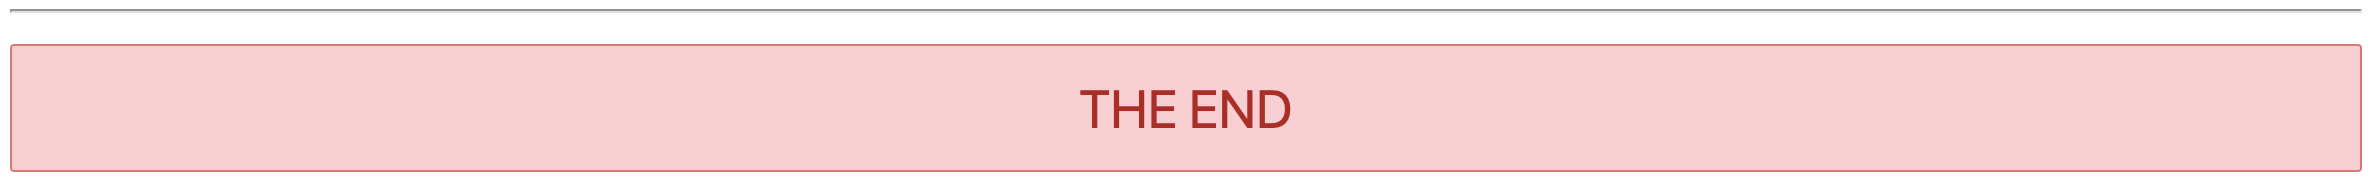